In [32]:
import os
import gmsh
import numpy as np
import typing
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import sys 
from matplotlib.ticker import FormatStrFormatter
sys.path.append("./")
sys.path.append("/mnt/c/21_Uni_other/mech/py/")
import hdf5_tools as h5t

class SensorArray:
    def __init__(self,filename: str) -> None:
        data = np.loadtxt(filename,delimiter=",",skiprows=1)
        self.NumberDatapoints = np.size(data,0)
        self.NodeCoordinates = data[:,1:4]
        self.RealValue = data[:,4:7]
        self.ElementCoordinates = data[:,7:10]
    
    def getNodeCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.NodeCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.NodeCoordinates[idx, :]
        
    def getElementCoordinates(self,idx:  typing.Optional[np.ndarray] = None) -> np.ndarray:
        if idx == None:
            return self.ElementCoordinates[:,:]
        else:
            if not np.issubdtype(idx.dtype, np.integer):  
                raise ValueError("Index array must contain integers.")

            if np.any(idx < 0) or np.any(idx >= self.NumberDatapoints):  
                raise IndexError("Index out of range.")
            
            return self.ElementCoordinates[idx, :]
        
def OperaTable(filename):
    with open(filename, "r") as file:
        lines = file.readlines()
    
    # Dewtermine number of datapoints
    first_line = lines[0].strip()
    counts = list(map(int, first_line.split()))
    num_data_points = counts[0] * counts[1] * counts[2] 
    
    # Extract Header
    column_names = []
    for line in lines[1:]:
        line = line.strip()
        if line == "0":  # Ende des Headers
            break
        column_name = re.sub(r"^\d+\s+|\[.*?\]", "", line).strip() 
        column_names.append(column_name)
    
    # Get Data
    data_start_index = lines.index(" 0\n") + 1  # First index after row with "0\n"
    data_lines = lines[data_start_index:data_start_index + num_data_points]
    
    # Convert Data
    data = [list(map(float, line.split())) for line in data_lines]
    df = pd.DataFrame(data, columns=column_names)
    
    return df

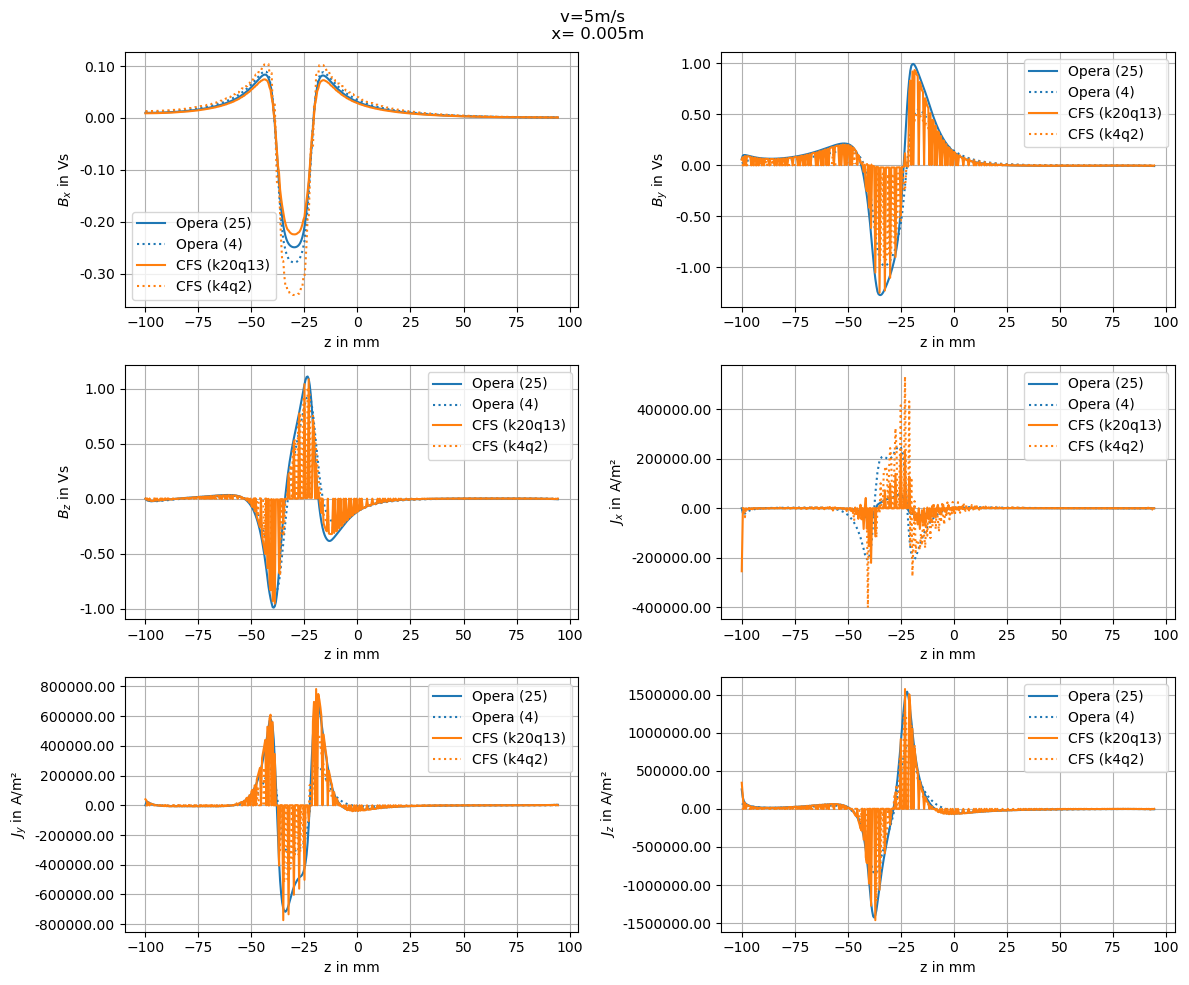

In [57]:
v=5

cfs_flux = SensorArray(f"sensorArray/movCond_k16_q10_v{v}_flux_rail.csv-1")      #movCond_k20_q13_v{v}_flux_rail
cfs_current = SensorArray(f"sensorArray/movCond_k16_q10_v{v}_curent_rail.csv-1")
cfs_flux_bad = SensorArray(f"sensorArray/movCond_k4_q2_v{v}_flux_rail.csv-1")      #movCond_k20_q13_v{v}_flux_rail
cfs_current_bad = SensorArray(f"sensorArray/movCond_k4_q2_v{v}_curent_rail.csv-1")

opera = OperaTable(f"OperaRes/coil_velocity_25_rail_{v}.table")
opera_bad = OperaTable(f"OperaRes/coil_velocity_4_rail_{v}.table")

x = 1604
idx =np.arange(x, x+390)


fig, ax = plt.subplots(3, 2, figsize=(12, 10))
ax = ax.flatten() 
for j, component in enumerate(["B_x", "B_y", "B_z", "J_x", "J_y", "J_z"]):
    ax[j].plot(1E3*opera["Z"][idx],opera[component.replace("_", "")][idx], linestyle='-', color="C0",label=f"Opera (25)")
    ax[j].plot(1E3*opera_bad["Z"][idx],opera_bad[component.replace("_", "")][idx], linestyle=':', color="C0",label=f"Opera (4)")
    
    if j < 3: 
        cfsData = cfs_flux
        cfsData_bad = cfs_flux_bad
        unitStr = "Vs"
    elif j < 6: 
        cfsData = cfs_current
        cfsData_bad = cfs_current_bad
        unitStr = "A/m²"

    cfsCoordinates = cfsData.getNodeCoordinates()
    ax[j].plot(1E3*cfsCoordinates[:,2][idx],cfsData.RealValue[:,j%3][idx], linestyle='-', color="C1" ,label=f"CFS (k20q13)")
    ax[j].plot(1E3*cfsCoordinates[:,2][idx],cfsData_bad.RealValue[:,j%3][idx], linestyle=':', color="C1" ,label=f"CFS (k4q2)")

    ax[j].set_xlabel("z in mm")
    ax[j].set_ylabel(f"${component}$ in {unitStr}")
    ax[j].grid()

    if j < 3:
        pass
    elif j <6:
        ax[j].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax[j].ticklabel_format(style='sci', axis='y', scilimits=(4,4))  # Erzwingt 1e4-Format

    ax[j].legend()
    ax[j].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    fig.subplots_adjust(left=0.15)
fig.suptitle(f"v={v}m/s \n x= {cfsCoordinates[:,0][idx][0]}m")
fig.tight_layout()
fig.savefig(f"plots/v{v}_x{1E3*cfsCoordinates[:,0][idx][0]}.pdf", dpi=300, bbox_inches="tight")
plt.show()

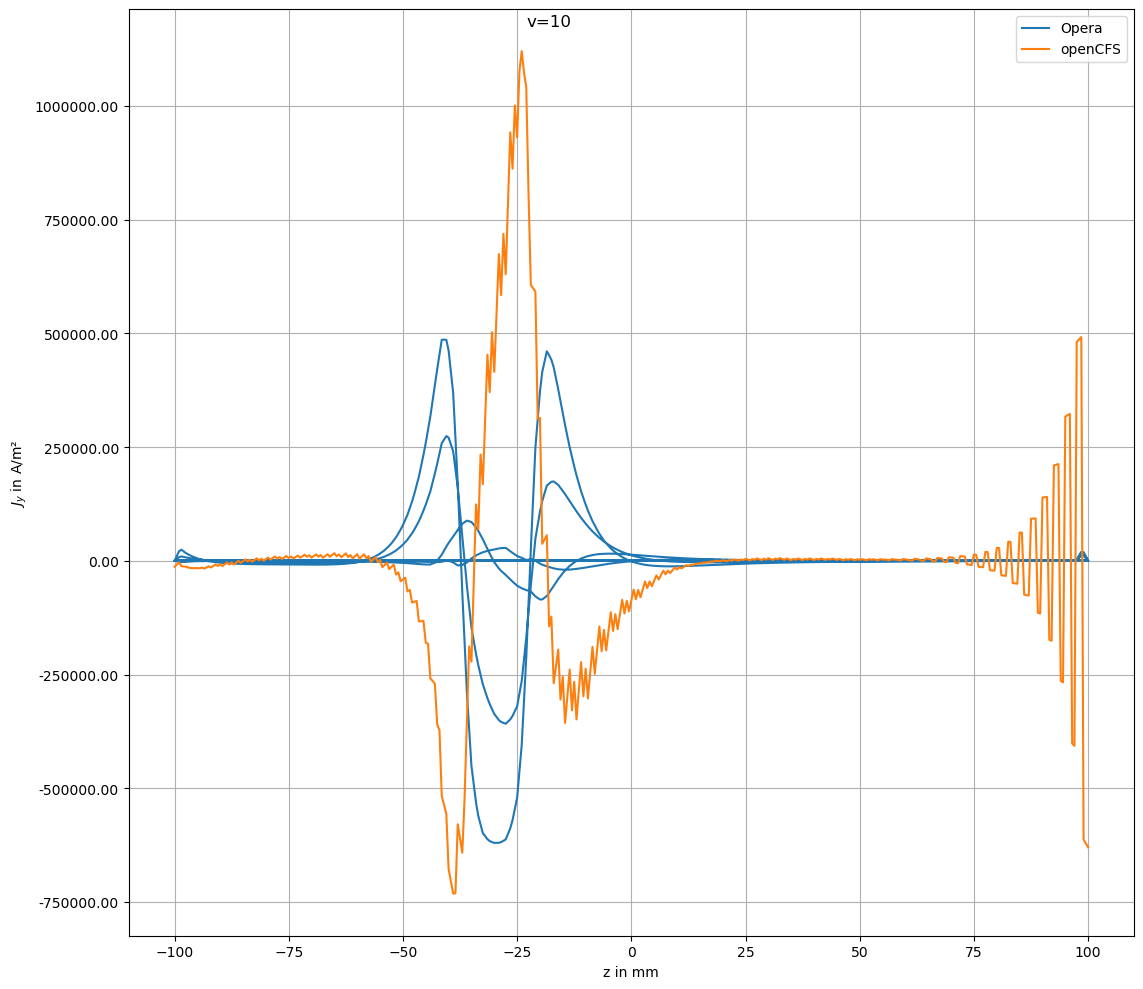

In [ ]:
# single plot
v=10
# Read Sensor Array
cfs_flux = SensorArray(f"sensorArray/flux_rail_v{v}.csv-1")
cfs_current = SensorArray(f"sensorArray/current_rail_v{v}.csv-1")
opera = OperaTable(f"OperaRes/coil_velocity_4_rail_{v}.table")

fig, ax = plt.subplots(figsize=(12, 10))

j=3
component="J_y"
ax.plot(1E3*opera["Z"],opera[component.replace("_", "")], linestyle='-',label=f"Opera")

if j < 3: 
    cfsData = cfs_flux
    unitStr = "Vs"
elif j < 6: 
    cfsData = cfs_current
    unitStr = "A/m²"

cfsCoordinates = cfsData.getNodeCoordinates()
ax.plot(1E3*cfsCoordinates[:,2],cfsData.RealValue[:,j%3], linestyle='-',label=f"openCFS")
ax.set_xlabel("z in mm")
ax.set_ylabel(f"${component}$ in {unitStr}")
ax.grid()

if j < 3:
    pass
elif j <6:
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(4,4))

ax.legend()
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
fig.tight_layout()
fig.subplots_adjust(left=0.15)
fig.suptitle(f"v={v}")
fig.savefig(f"plots/v_{v}.pdf", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_950/631947887.py:17: RuntimeWarning: divide by zero encountered in log10
  ax.plot(H, np.log10(H)-2, label="log10(B)", linestyle="-", marker="x")


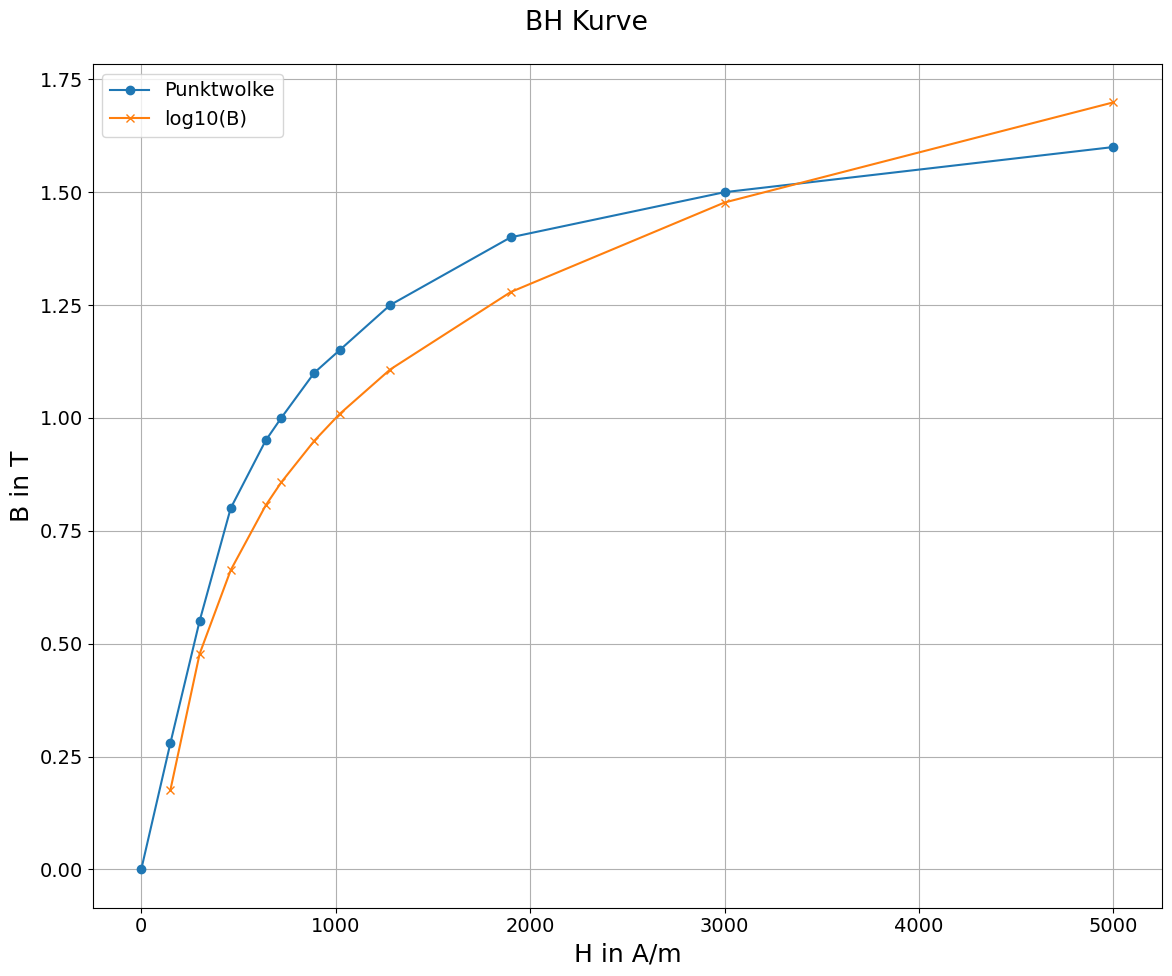

In [ ]:
# bh curve

plt.rcParams.update({
    "font.size": 16,       # base font size
    "axes.labelsize": 18,  # x and y labels
    "axes.titlesize": 20,  # title
    "legend.fontsize": 14, # legend
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

H = np.array([0, 150, 300, 460, 640, 720, 890, 1020, 1280, 1900, 3000, 5000])
B = np.array([0, 0.28, 0.55, 0.8, 0.95, 1.0, 1.1, 1.15, 1.25, 1.4, 1.5, 1.6])

fig, ax = plt.subplots(figsize=(12, 10))
ax.plot(H, B, linestyle='-', label=f"Punktwolke", marker="o")
ax.plot(H, np.log10(H)-2, label="log10(B)", linestyle="-", marker="x")
ax.set_xlabel("H in A/m")
ax.set_ylabel(f"B in T")
plt.grid()
plt.legend()
fig.suptitle(f"BH Kurve")
fig.tight_layout()
fig.savefig(f"plots/BhKurve.pdf", dpi=300, bbox_inches="tight")
plt.show()

    

In [ ]:
# convergence
[14520, 115104, 374016, 865117, 1739595]
cfs_meshes = ["k4_q2", "k8_q5", "k12_q8", "k16_q10", "k20_q13"]
vs = [0,1,5,10]
data = []
graph_i = []
X = []
for m in cfs_meshes:
    dfnew = pd.read_csv(f'history/movCond_{m}_v1-magFlux-surfRegion-flux.csv')['magFlux_surfRegion_flux_flux_(Vs)'].iloc[0]
    X_ = h5t.get_coordinates(f"results_hdf5/movCond_{m}_v1.cfs") 
    X.append(np.array(X_).shape[0])
    graph_i.append(dfnew)
    print(X)

fig, ax = plt.subplots(figsize=(12, 10))
for v in [0,5,1,10]:
    noX = []
    U = []
    cfs_meshes = ["k4_q2", "k8_q5", "k12_q8", "k16_q10", "k20_q13"]
    for m in cfs_meshes:
        # cfs_flux = SensorArray(f"sensorArray/movCond_{m}_v{v}_flux_rail.csv-1")      #movCond_k20_q13_v{v}_flux_rail
        cfs_current = SensorArray(f"sensorArray/movCond_{m}_v{v}_curent_rail.csv-1")
        X_ = h5t.get_coordinates(f"results_hdf5/movCond_{m}_v{v}.cfs") 
        noX_ = np.array(X_).shape[0]
        noX.append(noX_)

        idx = np.where(X_[:,2] == 0.005)[0][0]
        U_ = cfs_current.RealValue[:,2][idx]
        U.append(U_)

    # cfs_flux_bad = SensorArray(f"sensorArray/movCond_k4_q2_v{v}_flux_rail.csv-1")      #movCond_k20_q13_v{v}_flux_rail
    # cfs_current_bad = SensorArray(f"sensorArray/movCond_k4_q2_v{v}_curent_rail.csv-1")


    ax.plot(noX, U, linestyle='-', label=f"{v}")
        
    ax.legend()
    # ax.yaxis.set_major_formatter(FormatStrFormatter('%.2e'))
fig.subplots_adjust(left=0.15)
fig.suptitle(f"v={v}m/s \n x= -0.025 m")
plt.grid()
fig.tight_layout()
fig.savefig(f"plots/Konvergenz.pdf", dpi=300, bbox_inches="tight")
plt.show()